# APR Reconstruction — BATCH mode
Adapted for Ludovic Leconte — Institut Pasteur de Montevideo

**Batch processing of a full folder of `.h5` files**

For each file, the notebook produces:
- Image panel (Confocal open / close / ISM+APR) with scale bar and counts colorbar
- **Shifts figure**: scatter + fingerprint (%) + 3 quivers (full / even / odd) on 5×5 grid
- FRC plots + summary bars (resolution + gain)
- Multi-page TIFFs of the 25 channels (raw AND APR-reassigned)
- Per-file diagnostic CSV + batch summary

**Note**: quiver arrows are auto-scaled per file for maximum readability. The maximum magnitude in nm is shown in each panel title to allow cross-file comparison.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
import glob
import csv
import traceback
import tifffile as tiff

from brighteyes_ism.dataio.mcs import load
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.FRC_lib as frc

print('✓ Imports OK')

✓ Imports OK


## 1. Select the folder to process

A dialog window opens to pick the folder containing the `.h5` files.

In [14]:
import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
FOLDER = filedialog.askdirectory(title='Pick the folder containing the .h5 files')
root.destroy()

if not FOLDER:
    raise RuntimeError('No folder selected.')

h5_files = sorted(glob.glob(os.path.join(FOLDER, '*.h5')))
h5_files = [f for f in h5_files if not any(
    s in os.path.basename(f).lower() for s in ['_calib', '_irf', '_ref']
)]

save_dir = os.path.join(FOLDER, 'diagnostic')
os.makedirs(save_dir, exist_ok=True)

print(f'Folder       : {FOLDER}')
print(f'Output       : {save_dir}')
print(f'.h5 files    : {len(h5_files)}')
for i, f in enumerate(h5_files):
    print(f'  [{i:2d}] {os.path.basename(f)}')

Dossier      : D:/SpadArray/Giuseppe/atto647-microtubule
Output       : D:/SpadArray/Giuseppe/atto647-microtubule\diagnostic
Fichiers .h5 : 1
  [ 0] 03_Tub_Atto647N_HeLa-17-04-2026-16-01-33.h5


## 2. Processing parameters

In [15]:
# APR parameters
USF = 10            # upsampling factor for cross-correlation
REF_CHANNEL = 12    # central channel of a 5x5 SPAD

# Display
SHOW_FIGURES = True
DPI = 150

# What to save
SAVE_TIFF_CHANNELS_RAW = True    # 25 raw channels
SAVE_TIFF_CHANNELS_APR = True    # 25 APR-reassigned channels
SAVE_TIFF_SUMS = True            # summed images

print(f'USF={USF}, ref=ch{REF_CHANNEL}')

USF=10, ref=ch12


## 3. Utility functions

In [16]:
def save_25ch_tiff(channels_yxc, filepath, pixel_size_um):
    stack = np.moveaxis(channels_yxc, -1, 0).astype(np.float32)
    resolution = (1e4 / pixel_size_um, 1e4 / pixel_size_um)
    tiff.imwrite(filepath, stack, resolution=resolution,
                 metadata={'unit': 'um', 'axes': 'CYX'}, imagej=True)

def save_2d_tiff(img, filepath, pixel_size_um):
    resolution = (1e4 / pixel_size_um, 1e4 / pixel_size_um)
    tiff.imwrite(filepath, img.astype(np.float32),
                 resolution=resolution, metadata={'unit': 'um'}, imagej=True)

def compute_shifts(data, usf=10, ref=12):
    """Compute APR shifts for full / even-timebins / odd-timebins.
    Returns (shift_full, shift_even, shift_odd) in pixels, each shape (25, 2)."""
    dset_full = np.sum(data, axis=(0, 1, 4))
    shift_full, _ = apr.APR(dset_full, usf, ref)
    
    data_t = data.sum(axis=(0, 1))   # (y, x, t, ch)
    dset_even = data_t[:, :, ::2, :].sum(axis=-2)
    dset_odd  = data_t[:, :, 1::2, :].sum(axis=-2)
    shift_even, _ = apr.APR(dset_even, usf, ref)
    shift_odd,  _ = apr.APR(dset_odd,  usf, ref)
    
    return np.asarray(shift_full), np.asarray(shift_even), np.asarray(shift_odd)

def draw_quiver(ax, shift_xy_nm, color, title, n_side=5, ref=12):
    """Draw 5x5 quiver: exact replica of the old working script.
    grid[row, col] = shift_vectors[ch] then quiver(X, Y, grid[:,:,0], -grid[:,:,1])."""
    # Build (5, 5, 2) grid: grid[row, col, :] = (dx, dy) of channel ch
    grid = np.zeros((n_side, n_side, 2))
    for ch in range(n_side * n_side):
        row, col = ch // n_side, ch % n_side
        grid[row, col] = shift_xy_nm[ch]
    
    X, Y = np.meshgrid(np.arange(n_side), np.arange(n_side))
    # Auto-scale: pick scale based on max magnitude so longest arrow ~0.8 grid cell
    max_mag = float(np.linalg.norm(shift_xy_nm, axis=1).max())
    scale = max(max_mag / 0.4, 1.0)   # smaller divisor -> longer arrows
    
    ax.quiver(X, Y, grid[:, :, 0], -grid[:, :, 1],
              scale=scale, scale_units='xy', angles='xy',
              color=color, width=0.008,
              headwidth=4, headlength=5, zorder=2)
    # Channel labels
    for ch in range(n_side * n_side):
        row, col = ch // n_side, ch % n_side
        ax.text(col, row, f'{ch}', ha='center', va='center',
                fontsize=7, color='gray', zorder=1)
    # Reference marker (orange)
    ref_row, ref_col = ref // n_side, ref % n_side
    ax.scatter([ref_col], [ref_row], color='orange', s=100,
               edgecolors='black', zorder=5, label=f'ref ch{ref}')
    ax.set_xlim(-0.5, n_side - 0.5)
    ax.set_ylim(-0.5, n_side - 0.5)
    ax.invert_yaxis()   # exactly as in the old working script
    ax.set_xticks(range(n_side)); ax.set_yticks(range(n_side))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(title, fontsize=10)
    ax.legend(loc='upper right', fontsize=8)

print('✓ Utility functions defined')

✓ Fonctions utilitaires définies


## 4. Batch processing

Single pass: each file is processed independently. Quiver arrows are auto-scaled per file (maximum readability). The maximum magnitude in nm is shown in each panel title to compare across files.


[1/1]

Processing: 03_Tub_Atto647N_HeLa-17-04-2026-16-01-33
  Shape       : (1, 1, 1001, 1001, 64, 25)
  Pixel size  : 50.0 nm
  Dwell time  : 64.0 µs


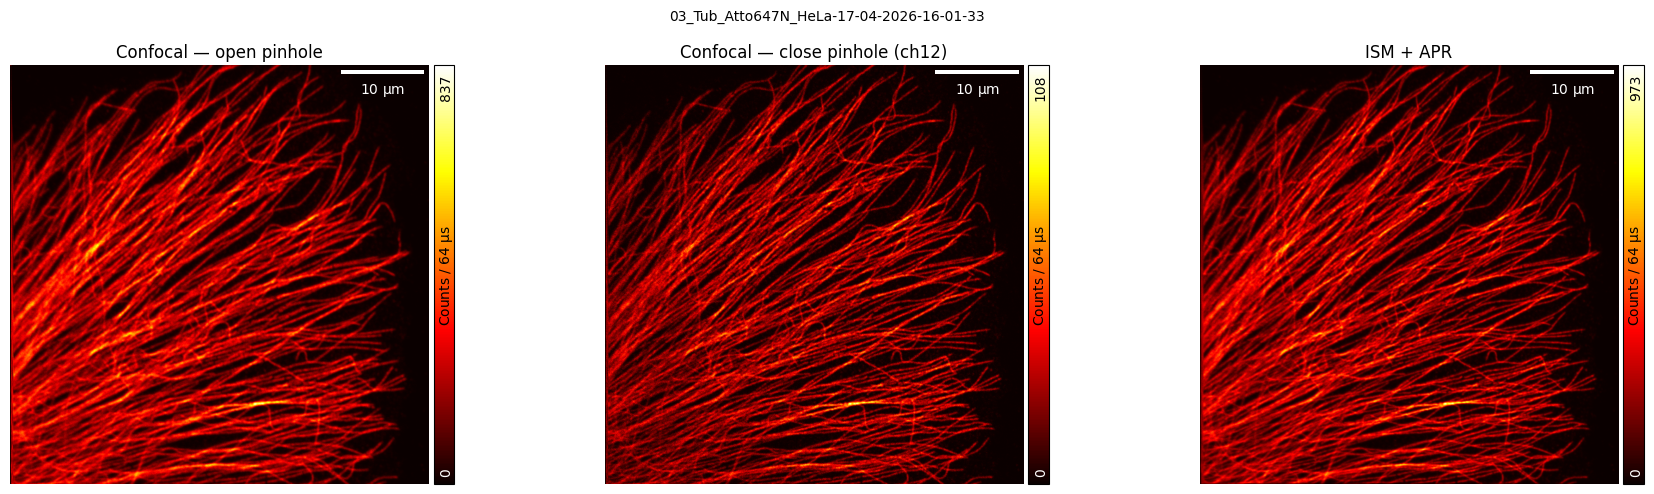

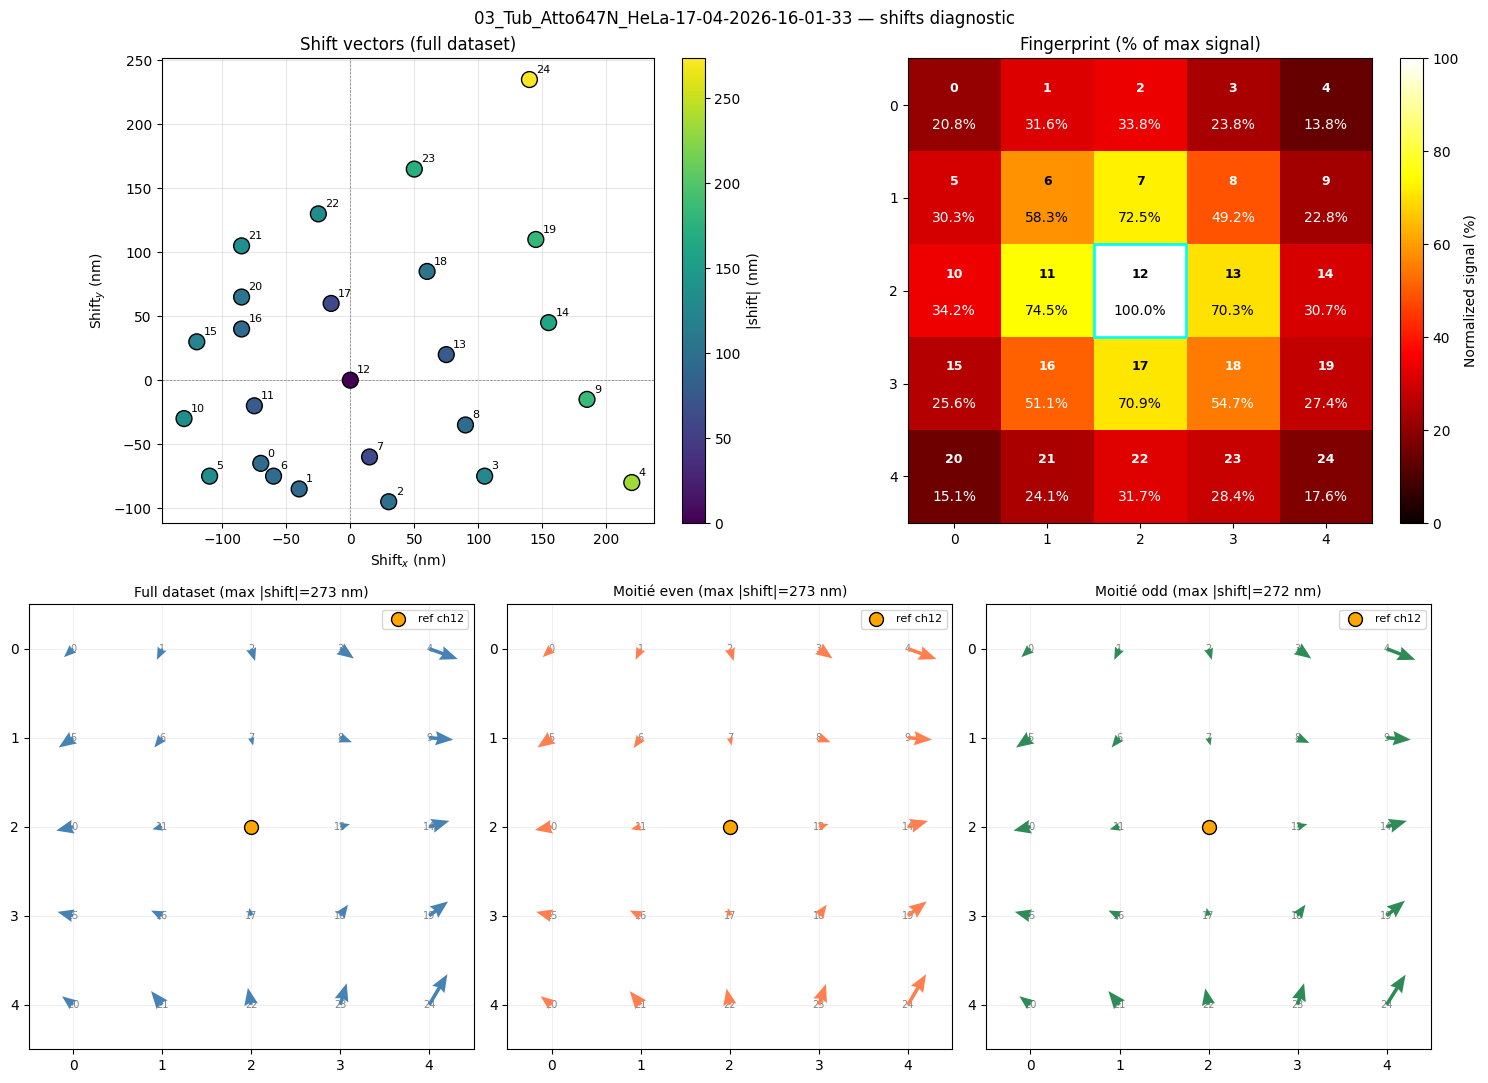

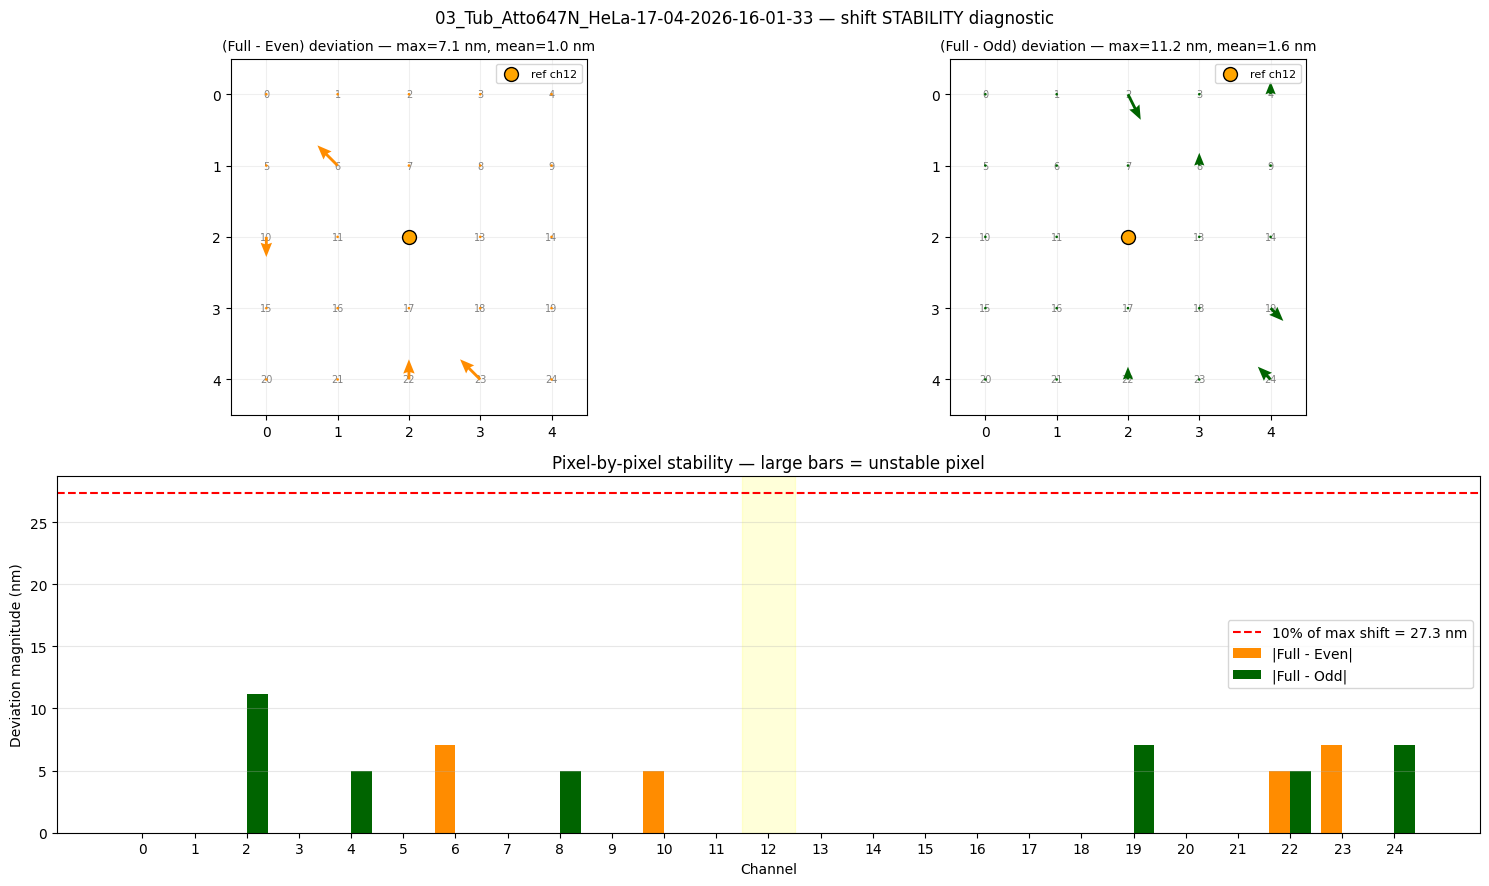

  Top 5 unstable channels (by |full-even|+|full-odd|):
    ch02: |full-even|=   0.0 nm, |full-odd|=  11.2 nm
    ch22: |full-even|=   5.0 nm, |full-odd|=   5.0 nm
    ch24: |full-even|=   0.0 nm, |full-odd|=   7.1 nm
    ch06: |full-even|=   7.1 nm, |full-odd|=   0.0 nm
    ch19: |full-even|=   0.0 nm, |full-odd|=   7.1 nm
  FRC Confocal : 277.3 nm
  FRC ISM+APR  : 205.4 nm
  Gain         : 1.35x


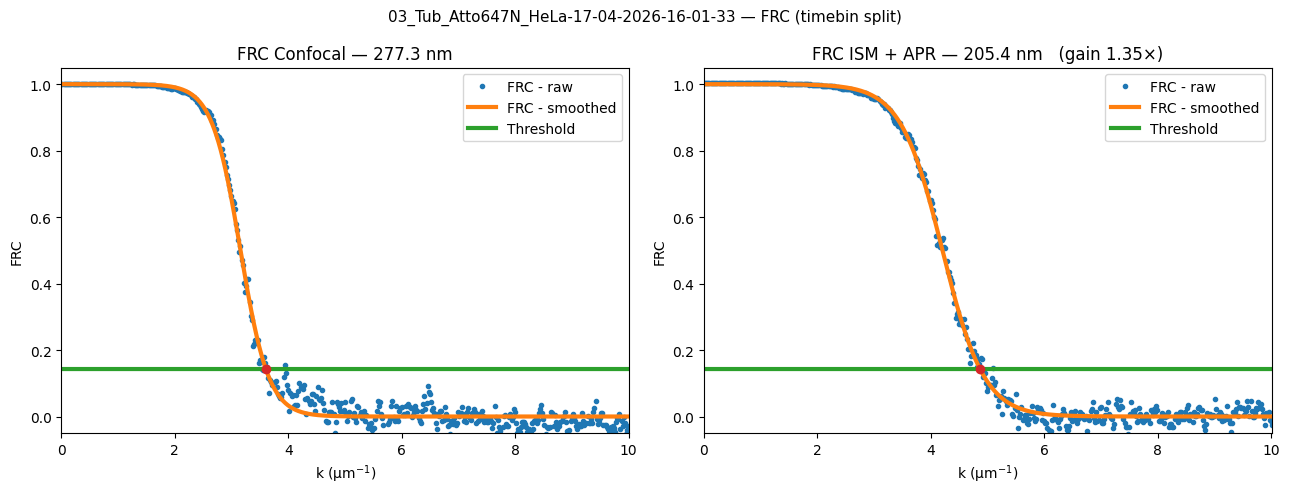

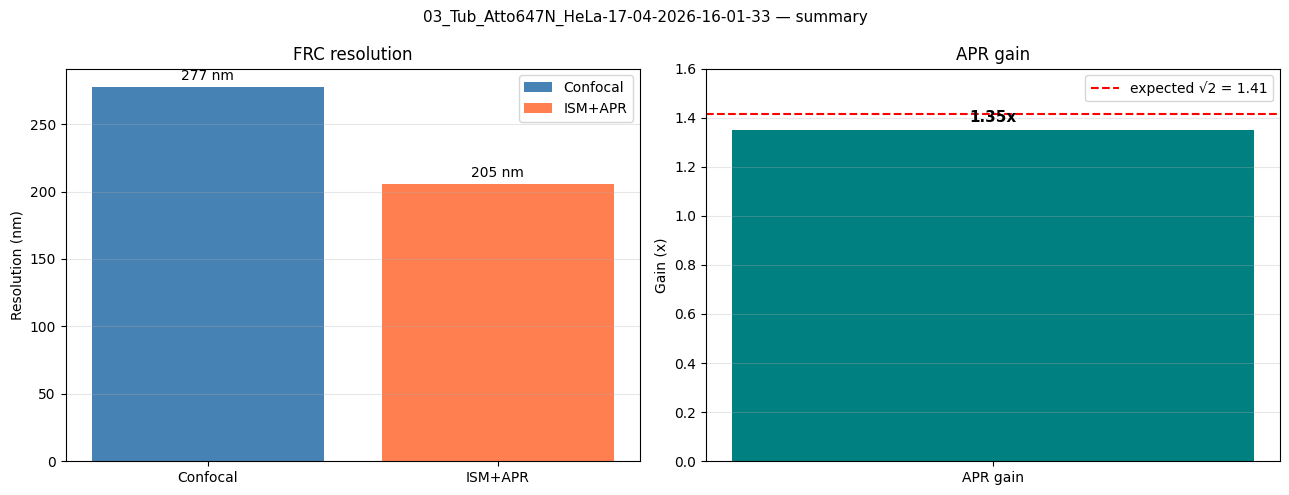


BATCH TERMINE : 1 OK, 0 échec(s)


In [17]:
def process_file(filepath, save_dir, usf=10, ref=12, show=True, dpi=150):
    """Process one .h5 file end-to-end."""
    basename = os.path.splitext(os.path.basename(filepath))[0]
    print(f'\n{"="*70}\nProcessing: {basename}\n{"="*70}')
    
    # ----- Load -----
    data, meta = load(filepath)
    pixel_size_um = meta.dx
    pixel_size_nm = meta.dx * 1000
    dwell_us      = meta.pxdwelltime
    print(f'  Shape       : {data.shape}')
    print(f'  Pixel size  : {pixel_size_nm:.1f} nm')
    print(f'  Dwell time  : {dwell_us} µs')
    
    # ----- Compute shifts (full / even / odd) -----
    sf, se, so = compute_shifts(data, usf=usf, ref=ref)
    shift_full_nm = sf * pixel_size_nm
    shift_even_nm = se * pixel_size_nm
    shift_odd_nm  = so * pixel_size_nm
    
    # ----- Project (y, x, ch) -----
    dset = np.sum(data, axis=(0, 1, 4))
    ny, nx, n_ch = dset.shape
    n_side = int(np.sqrt(n_ch))
    intensity_sum           = dset.sum(-1)
    intensity_central_pixel = dset[:, :, ref]
    
    # ----- APR full -----
    shift_vec, apr_rec = apr.APR(dset, usf, ref)
    imm_sum_APR = np.sum(apr_rec, axis=-1)
    
    # ----- Figure: images panel -----
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    gra.ShowImg(intensity_sum,           pixel_size_um, dwell_us, fig=fig, ax=ax[0])
    gra.ShowImg(intensity_central_pixel, pixel_size_um, dwell_us, fig=fig, ax=ax[1])
    gra.ShowImg(imm_sum_APR,             pixel_size_um, dwell_us, fig=fig, ax=ax[2])
    ax[0].set_title('Confocal — open pinhole')
    ax[1].set_title(f'Confocal — close pinhole (ch{ref})')
    ax[2].set_title('ISM + APR')
    fig.suptitle(basename, fontsize=10)
    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, f'{basename}_images.png'), dpi=dpi, bbox_inches='tight')
    if show: plt.show()
    plt.close(fig)
    
    # ----- Figure: shifts (scatter + fingerprint + 3 quivers) -----
    fingerprint     = dset.sum(axis=(0, 1)).reshape(n_side, n_side)
    fingerprint_pct = 100.0 * fingerprint / fingerprint.max()
    
    fig = plt.figure(figsize=(15, 11))
    fig.suptitle(f'{basename} — shifts diagnostic', fontsize=12)
    
    # Row 1: scatter (left) + fingerprint (right)
    ax1 = plt.subplot2grid((2, 6), (0, 0), colspan=3)
    ax2 = plt.subplot2grid((2, 6), (0, 3), colspan=3)
    
    # Row 2: three quivers (full, even, odd)
    ax_qf = plt.subplot2grid((2, 6), (1, 0), colspan=2)
    ax_qe = plt.subplot2grid((2, 6), (1, 2), colspan=2)
    ax_qo = plt.subplot2grid((2, 6), (1, 4), colspan=2)
    
    # --- Scatter shift vectors (same convention as old script: dx on X, dy on Y) ---
    magnitudes = np.linalg.norm(shift_full_nm, axis=1)
    sc = ax1.scatter(shift_full_nm[:, 0], shift_full_nm[:, 1], c=magnitudes,
                     cmap='viridis', s=130, edgecolors='black', zorder=3)
    for i, (sx, sy) in enumerate(shift_full_nm):
        ax1.annotate(str(i), (sx, sy), fontsize=8,
                     xytext=(5, 5), textcoords='offset points')
    ax1.axhline(0, color='gray', lw=0.5, ls='--')
    ax1.axvline(0, color='gray', lw=0.5, ls='--')
    ax1.set_xlabel('Shift$_x$ (nm)'); ax1.set_ylabel('Shift$_y$ (nm)')
    ax1.set_title('Shift vectors (full dataset)')
    ax1.set_aspect('equal'); ax1.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax1, label='|shift| (nm)', fraction=0.046, pad=0.04)
    
    # --- Fingerprint with % ---
    im = ax2.imshow(fingerprint_pct, cmap='hot', vmin=0, vmax=100)
    ax2.set_title('Fingerprint (% of max signal)')
    ax2.set_xticks(range(n_side)); ax2.set_yticks(range(n_side))
    for r in range(n_side):
        for c in range(n_side):
            ch_idx = r * n_side + c
            pct    = fingerprint_pct[r, c]
            color  = 'black' if pct > 55 else 'white'
            ax2.text(c, r - 0.18, f'{ch_idx}', ha='center', va='center',
                     color=color, fontsize=9, fontweight='bold')
            ax2.text(c, r + 0.22, f'{pct:.1f}%', ha='center', va='center',
                     color=color, fontsize=10)
    center = n_side // 2
    ax2.add_patch(Rectangle((center - 0.5, center - 0.5), 1, 1,
                            fill=False, edgecolor='cyan', lw=2))
    plt.colorbar(im, ax=ax2, label='Normalized signal (%)', fraction=0.046, pad=0.04)
    
    # --- Quivers ---
    draw_quiver(ax_qf, shift_full_nm, color='steelblue',
                title=f'Full dataset (max |shift|={np.linalg.norm(shift_full_nm, axis=1).max():.0f} nm)',
                n_side=n_side, ref=ref)
    draw_quiver(ax_qe, shift_even_nm, color='coral',
                title=f'Even half (max |shift|={np.linalg.norm(shift_even_nm, axis=1).max():.0f} nm)',
                n_side=n_side, ref=ref)
    draw_quiver(ax_qo, shift_odd_nm,  color='seagreen',
                title=f'Odd half (max |shift|={np.linalg.norm(shift_odd_nm, axis=1).max():.0f} nm)',
                n_side=n_side, ref=ref)
    
    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, f'{basename}_shifts_full.png'),
                dpi=dpi, bbox_inches='tight')
    if show: plt.show()
    plt.close(fig)
    
    # ----- NEW Figure: stability diagnostic (full - even) and (full - odd) -----
    diff_even = shift_full_nm - shift_even_nm   # (25, 2)
    diff_odd  = shift_full_nm - shift_odd_nm    # (25, 2)
    diff_even_mag = np.linalg.norm(diff_even, axis=1)
    diff_odd_mag  = np.linalg.norm(diff_odd,  axis=1)
    
    fig = plt.figure(figsize=(15, 9))
    fig.suptitle(f'{basename} — shift STABILITY diagnostic', fontsize=12)
    
    # Row 1: two quivers showing the deviations
    ax_qe = plt.subplot2grid((2, 4), (0, 0), colspan=2)
    ax_qo = plt.subplot2grid((2, 4), (0, 2), colspan=2)
    
    draw_quiver(ax_qe, diff_even, color='darkorange',
                title=f'(Full - Even) deviation — max={diff_even_mag.max():.1f} nm, mean={diff_even_mag.mean():.1f} nm',
                n_side=n_side, ref=ref)
    draw_quiver(ax_qo, diff_odd, color='darkgreen',
                title=f'(Full - Odd) deviation — max={diff_odd_mag.max():.1f} nm, mean={diff_odd_mag.mean():.1f} nm',
                n_side=n_side, ref=ref)
    
    # Row 2: bar chart of deviation magnitudes per channel
    ax_bar = plt.subplot2grid((2, 4), (1, 0), colspan=4)
    x = np.arange(n_side * n_side)
    width = 0.4
    ax_bar.bar(x - width/2, diff_even_mag, width, color='darkorange', label='|Full - Even|')
    ax_bar.bar(x + width/2, diff_odd_mag,  width, color='darkgreen',  label='|Full - Odd|')
    # Threshold suggestion : 10% of max full shift
    threshold = 0.1 * np.linalg.norm(shift_full_nm, axis=1).max()
    ax_bar.axhline(threshold, color='red', ls='--',
                   label=f'10% of max shift = {threshold:.1f} nm')
    ax_bar.set_xlabel('Channel')
    ax_bar.set_ylabel('Deviation magnitude (nm)')
    ax_bar.set_title('Pixel-by-pixel stability — large bars = unstable pixel')
    ax_bar.set_xticks(x)
    ax_bar.legend()
    ax_bar.grid(alpha=0.3, axis='y')
    # Mark reference channel
    ax_bar.axvspan(ref - 0.5, ref + 0.5, color='yellow', alpha=0.15)
    
    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, f'{basename}_shifts_stability.png'),
                dpi=dpi, bbox_inches='tight')
    if show: plt.show()
    plt.close(fig)
    
    # Print top unstable channels (helpful in console)
    instab_total = diff_even_mag + diff_odd_mag
    worst = np.argsort(instab_total)[::-1][:5]
    print('  Top 5 unstable channels (by |full-even|+|full-odd|):')
    for ch in worst:
        print(f'    ch{ch:02d}: |full-even|={diff_even_mag[ch]:6.1f} nm, |full-odd|={diff_odd_mag[ch]:6.1f} nm')
    
    # ----- FRC -----
    data_split = data.sum(axis=(0, 1))
    data_split = [data_split[:, :, ::2, :], data_split[:, :, 1::2, :]]
    images_sum, images_ism = [], []
    for n in range(2):
        img = data_split[n].sum(axis=-2)
        images_sum.append(img.sum(axis=-1))
        images_ism.append(apr.APR(img, usf, ref)[1].sum(axis=-1))
    
    frc_sum = frc.FRC_resolution(images_sum[0], images_sum[1],
                                 px=pixel_size_um, method='fixed', smoothing='fit')
    frc_ism = frc.FRC_resolution(images_ism[0], images_ism[1],
                                 px=pixel_size_um, method='fixed', smoothing='fit')
    res_confocal_nm = frc_sum[0] * 1000
    res_apr_nm      = frc_ism[0] * 1000
    gain = (res_confocal_nm / res_apr_nm) if res_apr_nm else float('nan')
    print(f'  FRC Confocal : {res_confocal_nm:.1f} nm')
    print(f'  FRC ISM+APR  : {res_apr_nm:.1f} nm')
    print(f'  Gain         : {gain:.2f}x')
    
    # ----- Figure: FRC plots -----
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{basename} — FRC (timebin split)', fontsize=11)
    try:
        fig, ax[0] = frc.plotFRC(*frc_sum, fig=fig, ax=ax[0])
        fig, ax[1] = frc.plotFRC(*frc_ism, fig=fig, ax=ax[1])
    except TypeError:
        frc.plotFRC(*frc_sum, fig=fig, ax=ax[0])
        frc.plotFRC(*frc_ism, fig=fig, ax=ax[1])
    ax[0].set_title(f'FRC Confocal — {res_confocal_nm:.1f} nm')
    ax[1].set_title(f'FRC ISM + APR — {res_apr_nm:.1f} nm   (gain {gain:.2f}×)')
    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, f'{basename}_frc.png'), dpi=dpi, bbox_inches='tight')
    if show: plt.show()
    plt.close(fig)
    
    # ----- Figure: summary bars -----
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{basename} — summary', fontsize=11)
    a = axes[0]
    a.bar(['Confocal'], [res_confocal_nm], color='steelblue', label='Confocal')
    a.bar(['ISM+APR'],  [res_apr_nm],      color='coral',     label='ISM+APR')
    a.set_ylabel('Resolution (nm)'); a.set_title('FRC resolution')
    a.legend(); a.grid(alpha=0.3, axis='y')
    for i, v in enumerate([res_confocal_nm, res_apr_nm]):
        a.text(i, v + max(res_confocal_nm, res_apr_nm) * 0.02,
               f'{v:.0f} nm', ha='center', fontsize=10)
    a = axes[1]
    a.bar(['APR gain'], [gain], color='teal')
    a.axhline(np.sqrt(2), color='red', ls='--', label=f'expected √2 = {np.sqrt(2):.2f}')
    a.set_ylabel('Gain (x)'); a.set_title('APR gain')
    a.set_ylim(0, max(1.6, gain * 1.15))
    a.legend(); a.grid(alpha=0.3, axis='y')
    a.text(0, gain + 0.03, f'{gain:.2f}x', ha='center', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, f'{basename}_summary.png'), dpi=dpi, bbox_inches='tight')
    if show: plt.show()
    plt.close(fig)
    
    # ----- TIFF exports -----
    if SAVE_TIFF_SUMS:
        save_2d_tiff(intensity_sum,           os.path.join(save_dir, f'{basename}_confocal_open.tif'),  pixel_size_um)
        save_2d_tiff(intensity_central_pixel, os.path.join(save_dir, f'{basename}_confocal_close.tif'), pixel_size_um)
        save_2d_tiff(imm_sum_APR,             os.path.join(save_dir, f'{basename}_ism_apr.tif'),        pixel_size_um)
    if SAVE_TIFF_CHANNELS_RAW:
        save_25ch_tiff(dset, os.path.join(save_dir, f'{basename}_channels_raw_25ch.tif'), pixel_size_um)
    if SAVE_TIFF_CHANNELS_APR:
        save_25ch_tiff(apr_rec, os.path.join(save_dir, f'{basename}_channels_apr_25ch.tif'), pixel_size_um)
    
    # ----- Diagnostic CSV -----
    csv_path = os.path.join(save_dir, f'{basename}_diagnostic.csv')
    with open(csv_path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['file', 'pixel_size_nm', 'dwell_us',
                    'res_confocal_nm', 'res_apr_nm', 'gain'])
        w.writerow([basename, pixel_size_nm, dwell_us,
                    f'{res_confocal_nm:.1f}', f'{res_apr_nm:.1f}', f'{gain:.3f}'])
    
    return {
        'file': basename,
        'pixel_size_nm': pixel_size_nm,
        'dwell_us': dwell_us,
        'res_confocal_nm': res_confocal_nm,
        'res_apr_nm': res_apr_nm,
        'gain': gain,
    }

results = []
failed  = []
for i, filepath in enumerate(h5_files):
    print(f'\n[{i+1}/{len(h5_files)}]')
    try:
        res = process_file(filepath, save_dir,
                           usf=USF, ref=REF_CHANNEL,
                           show=SHOW_FIGURES, dpi=DPI)
        results.append(res)
    except Exception as e:
        print(f'  ✗ FAILED: {e}')
        traceback.print_exc()
        failed.append((os.path.basename(filepath), str(e)))

print(f'\n{"="*70}')
print(f'BATCH FINISHED : {len(results)} OK, {len(failed)} failure(s)')
print(f'{"="*70}')
if failed:
    print('\nFailed files:')
    for name, err in failed:
        print(f'  - {name} : {err}')

## 5. Batch summary

CSV synthèse : D:/SpadArray/Giuseppe/atto647-microtubule\diagnostic\BATCH_summary.csv


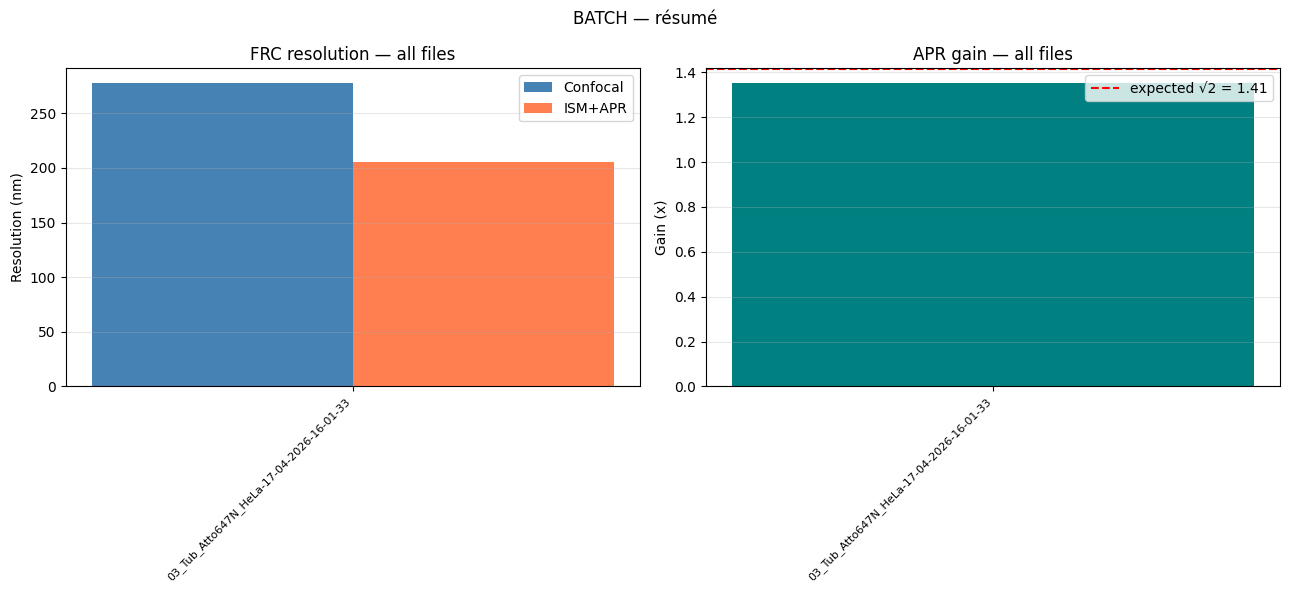

PNG synthèse : D:/SpadArray/Giuseppe/atto647-microtubule\diagnostic\BATCH_summary.png


In [18]:
if results:
    summary_csv = os.path.join(save_dir, 'BATCH_summary.csv')
    with open(summary_csv, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['file', 'pixel_size_nm', 'dwell_us',
                    'res_confocal_nm', 'res_apr_nm', 'gain'])
        for r in results:
            w.writerow([r['file'], r['pixel_size_nm'], r['dwell_us'],
                        f"{r['res_confocal_nm']:.1f}",
                        f"{r['res_apr_nm']:.1f}",
                        f"{r['gain']:.3f}"])
    print(f'Summary CSV : {summary_csv}')
    
    names    = [r['file'] for r in results]
    res_conf = [r['res_confocal_nm'] for r in results]
    res_apr  = [r['res_apr_nm']      for r in results]
    gains    = [r['gain']            for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(max(13, len(names)*1.2), 6))
    fig.suptitle('BATCH — summary', fontsize=12)
    
    x = np.arange(len(names))
    width = 0.4
    a = axes[0]
    a.bar(x - width/2, res_conf, width, color='steelblue', label='Confocal')
    a.bar(x + width/2, res_apr,  width, color='coral',     label='ISM+APR')
    a.set_ylabel('Resolution (nm)')
    a.set_title('FRC resolution — all files')
    a.set_xticks(x); a.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    a.legend(); a.grid(alpha=0.3, axis='y')
    
    a = axes[1]
    a.bar(x, gains, color='teal')
    a.axhline(np.sqrt(2), color='red', ls='--', label=f'expected √2 = {np.sqrt(2):.2f}')
    a.set_ylabel('Gain (x)')
    a.set_title('APR gain — all files')
    a.set_xticks(x); a.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    a.legend(); a.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, 'BATCH_summary.png'), dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'Summary PNG : {os.path.join(save_dir, "BATCH_summary.png")}')
else:
    print('No results to summarize.')